<a href="https://colab.research.google.com/github/Mathildeholst/Case/blob/main/OTARI_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load og hent data til Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

folder = "/content/drive/MyDrive/OTARI_case"

finance_path = f"{folder}/Finance.csv"
companies_path = f"{folder}/Companies.csv"

In [3]:
finance = pd.read_csv(finance_path)
companies = pd.read_csv(companies_path)

companies.columns = companies.columns.str.strip()
finance.columns = finance.columns.str.strip()

Det nye der skal køres efter datarensning

In [ ]:
import pandas as pd

latest_data = pd.read_pickle(
    "/content/drive/MyDrive/OTARI_case/latest_data.pkl"
)

#Step 1: Data understanding & quality

Se kolonnenavne, struktur og hvordan værdierne ser ud

In [ ]:
import pandas as pd

finance_path = "/content/drive/MyDrive/OTARI_case/Finance.csv"
companies_path = "/content/drive/MyDrive/OTARI_case/Companies.csv"

finance_sample = pd.read_csv(finance_path, nrows=10)
companies_sample = pd.read_csv(companies_path, nrows=10)

print("FINANCE")
display(finance_sample)

print("\nCOMPANIES")
display(companies_sample)

FINANCE


,CVR,LocalName,Value,Context,SlutDato,InstantDate,DocType,DKLabel
0,32945856,AverageNumberOfEmployees,1,D0,2025-06-30,NaN,AARSRAPPORT,Antal ansatte
1,32945856,GrossProfitLoss,-17595,D0,2025-06-30,NaN,AARSRAPPORT,Brutto fortjeneste
2,32945856,OtherFinanceIncome,36365,D0,2025-06-30,NaN,AARSRAPPORT,Andre finansielle indtægter
3,32945856,OtherFinanceExpenses,0,D0,2025-06-30,NaN,AARSRAPPORT,Andre finansielle udgifter
4,32945856,ProfitLossFromOrdinaryActivitiesBeforeTax,18770,D0,2025-06-30,NaN,AARSRAPPORT,Resultat før skat
5,32945856,ProfitLoss,14986,D0,2025-06-30,NaN,AARSRAPPORT,Resultat
6,32945856,Assets,4355073,I0,2025-06-30,2025-06-30,AARSRAPPORT,Balancesum
7,32945856,Equity,4109281,I0,2025-06-30,2025-06-30,AARSRAPPORT,Egenkapital
8,32945856,CashAndCashEquivalents,4155443,I0,2025-06-30,2025-06-30,AARSRAPPORT,Likvide beholdninger
9,32945856,LongtermLiabilitiesOtherThanProvisions,3784,I0,2025-06-30,2025-06-30,AARSRAPPORT,Langsigtede forpligtelser



COMPANIES


,UnitNumber,kommuneNavn,Postnummer,Navn,Branche,Cvr,Status
0,4004306483,VEJEN,6600,PHØNIX BELÆGNINGSTEKNIK A/S,NaN,20877014,OPLØSTEFTERFUSION
1,4004306484,NaN,3730,BALTIC BORN TECH A/S,NaN,76164010,OPLØSTEFTERFRIVILLIGLIKVIDATION
2,4004306485,BRØNDBY,2600,COMPUTERVISION DANMARK A/S,NaN,66616215,OPLØSTEFTERFUSION
3,4004306486,ODENSE,5250,TØMRERMESTER CHR. ELLEGAARD ANDERSEN A/S,NaN,76999910,OPLØSTEFTERFRIVILLIGLIKVIDATION
4,4004306487,HILLERØD,3400,"DATA-TIME, HILLERØD A/S",NaN,73333016,OPLØSTEFTERKONKURS
5,4004306488,HØRSHOLM,2960,SEAWEAR A/S,NaN,70646013,OPLØSTEFTERFRIVILLIGLIKVIDATION
6,4004306489,NaN,8900,"BENT JENSEN TAGDÆKNING, RANDERS, A/S",NaN,17670107,OPLØSTEFTERKONKURS
7,4004306490,KØBENHAVN,1019,"AKTIESELSKABET ""DET KØBENHAVNSKE EJENDOMS-SOCI...",NaN,14707700,OPLØSTEFTERKONKURS
8,4004306491,ODENSE,5100,A/S 21/2 1988 (BOOKER),NaN,39728818,OPLØSTEFTERFUSION
9,4004306492,FAKSE,4640,A/S BRYGGERIET ODIN,NaN,45726916,OPLØSTEFTERFUSION


###Companies

In [ ]:
companies = pd.read_csv(companies_path)

print("Shape:", companies.shape)

print("\nDatatypes:")
display(companies.dtypes)

print("\nMissing values:")
display(
    companies.isna()
    .sum()
    .to_frame("Missing")
    .assign(Percent=lambda x: (x["Missing"] / len(companies) * 100).round(2))
)

print("\nUnique values:")
display(companies.nunique().to_frame("Unique"))

Shape: (2250983, 7)

Datatypes:


,0
UnitNumber,int64
kommuneNavn,object
Postnummer,float64
Navn,object
Branche,object
Cvr,int64
Status,object



Missing values:


,Missing,Percent
UnitNumber,0,0.00
kommuneNavn,58501,2.60
Postnummer,473,0.02
Navn,501,0.02
Branche,67894,3.02
Cvr,0,0.00
Status,1,0.00



Unique values:


,Unique
UnitNumber,2250983
kommuneNavn,330
Postnummer,1196
Navn,2179890
Branche,1754
Cvr,2250983
Status,22


In [ ]:
companies.columns = companies.columns.str.strip()

print(companies.columns.tolist())

['UnitNumber', 'kommuneNavn', 'Postnummer', 'Navn', 'Branche', 'Cvr', 'Status']


In [ ]:
print("COMPANY STATUS")
display(
    companies["Status"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print("\nMOST COMMON INDUSTRIES")
display(
    companies["Branche"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("Count")
)

print("\nMOST COMMON MUNICIPALITIES")
display(
    companies["kommuneNavn"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("Count")
)

COMPANY STATUS


,Count
Status,
Ophørt,934018
Aktiv,468717
NORMAL,390963
OPLØSTEFTERKONKURS,130507
OPLØSTEFTERERKLÆRING,106125
TVANGSOPLØST,85157
OPLØSTEFTERFRIVILLIGLIKVIDATION,57451
OPLØSTEFTERFUSION,41027
SLETTET,12314



MOST COMMON INDUSTRIES


,Count
Branche,
Ikke-finansielle holdingselskaber,176456
Uoplyst,111084
Andre organisationers og foreningers aktiviteter i.a.n.,104874
NaN,67894
Andre organisationer og foreninger i.a.n.,62711
Udlejning af erhvervsejendomme,61077
Virksomhedsrådgivning og anden ledelsesrådgivning,32159
"Dyrkning af korn (undtagen ris), bælgfrugter og olieholdige frø",30261
Computerprogrammering,29153



MOST COMMON MUNICIPALITIES


,Count
kommuneNavn,
KØBENHAVN,335487
AARHUS,124627
AALBORG,72601
ODENSE,64688
NaN,58501
FREDERIKSBERG,49367
GENTOFTE,46417
VEJLE,39545
ESBJERG,34158


####**Første observationer**
* Datasættet indeholder 2.250.983 virksomheder, og hvert CVR-nummer optræder kun én gang.
* Der mangler brancheoplysninger for ca. 3 % af virksomhederne.
* Virksomhedsstatus er ikke helt ensartet angivet, fx forskelle i brugen af store og små bogstaver.
* Branchebetegnelserne ser ud til at indeholde forskellige eller overlappende navngivninger.
  * Dette bør undersøges nærmere, inden de eventuelt standardiseres.

###Finance

In [ ]:
finance = pd.read_csv(finance_path, low_memory=False)

finance.columns = finance.columns.str.strip()

print("Shape:", finance.shape)

print("\nColumns:")
print(finance.columns.tolist())

print("\nDatatypes:")
display(finance.dtypes)

print("\nMemory usage:")
print(f"{finance.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: (3763613, 8)

Columns:
['CVR', 'LocalName', 'Value', 'Context', 'SlutDato', 'InstantDate', 'DocType', 'DKLabel']

Datatypes:


,0
CVR,int64
LocalName,object
Value,float64
Context,object
SlutDato,object
InstantDate,object
DocType,object
DKLabel,object



Memory usage:
1334.0 MB


In [ ]:
print("ANTAL UNIKKE VÆRDIER")
display(finance.nunique().to_frame("Antal unikke"))

print("\nMANGLENDE VÆRDIER")
missing_finance = pd.DataFrame({
    "Antal manglende": finance.isna().sum(),
    "Procent": (finance.isna().mean() * 100).round(2)
})
display(missing_finance)

print("\nANTAL UNIKKE VIRKSOMHEDER")
print(f"{finance['CVR'].nunique():,}".replace(",", "."))

print("\nDOKUMENTTYPER")
display(finance["DocType"].value_counts(dropna=False))

print("\n20 MEST FOREKOMMENDE REGNSKABSPOSTER")
display(
    finance["LocalName"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("Antal")
)

ANTAL UNIKKE VÆRDIER


,Antal unikke
CVR,356446
LocalName,17
Value,1672483
Context,399
SlutDato,165
InstantDate,165
DocType,1
DKLabel,17



MANGLENDE VÆRDIER


,Antal manglende,Procent
CVR,0,0.00
LocalName,0,0.00
Value,0,0.00
Context,0,0.00
SlutDato,0,0.00
InstantDate,2237220,59.44
DocType,0,0.00
DKLabel,0,0.00



ANTAL UNIKKE VIRKSOMHEDER
356.446

DOKUMENTTYPER


,count
DocType,
AARSRAPPORT,3763613



20 MEST FOREKOMMENDE REGNSKABSPOSTER


,Antal
LocalName,
ProfitLoss,365570
Equity,365437
Assets,365152
ShorttermLiabilitiesOtherThanProvisions,352052
ProfitLossFromOrdinaryActivitiesBeforeTax,347818
AverageNumberOfEmployees,340693
CashAndCashEquivalents,327100
GrossProfitLoss,310223
ProfitLossFromOrdinaryOperatingActivities,287545


In [ ]:
financial_items = (
    finance.groupby(["LocalName", "DKLabel"])
    .agg(
        Antal=("Value", "size"),
        Virksomheder=("CVR", "nunique"),
        Mangler_InstantDate=("InstantDate", lambda x: x.isna().sum()),
        Mangler_SlutDato=("SlutDato", lambda x: x.isna().sum())
    )
    .reset_index()
    .sort_values("Antal", ascending=False)
)

financial_items["Dækning_pct"] = (
    financial_items["Virksomheder"] / finance["CVR"].nunique() * 100
).round(1)

display(financial_items)

,LocalName,DKLabel,Antal,Virksomheder,Mangler_InstantDate,Mangler_SlutDato,Dækning_pct
11,ProfitLoss,Resultat,365570,356396,365570,0,100.0
3,Equity,Egenkapital,365437,356410,0,0,100.0
0,Assets,Balancesum,365152,356412,0,0,100.0
16,ShorttermLiabilitiesOtherThanProvisions,Kortsigtede forpligtelser,352052,343605,0,0,96.4
12,ProfitLossFromOrdinaryActivitiesBeforeTax,Resultat før skat,347818,339533,347818,0,95.3
1,AverageNumberOfEmployees,Antal ansatte,340693,324972,340693,0,91.2
2,CashAndCashEquivalents,Likvide beholdninger,327100,319087,0,0,89.5
5,GrossProfitLoss,Brutto fortjeneste,310223,303202,310223,0,85.1
13,ProfitLossFromOrdinaryOperatingActivities,Resultat af primær drift,287545,280821,287545,0,78.8
10,OtherFinanceIncome,Andre finansielle indtægter,268933,262411,268933,0,73.6


In [ ]:
finance["SlutDato_dt"] = pd.to_datetime(finance["SlutDato"], errors="coerce")
finance["InstantDate_dt"] = pd.to_datetime(finance["InstantDate"], errors="coerce")

print("SlutDato:")
print("Fra:", finance["SlutDato_dt"].min())
print("Til:", finance["SlutDato_dt"].max())

print("\nInstantDate:")
print("Fra:", finance["InstantDate_dt"].min())
print("Til:", finance["InstantDate_dt"].max())

SlutDato:
Fra: 2025-01-03 00:00:00
Til: 2026-07-31 00:00:00

InstantDate:
Fra: 2025-01-03 00:00:00
Til: 2026-07-31 00:00:00


In [ ]:
profit_counts = (
    finance[finance["LocalName"] == "ProfitLoss"]
    .groupby("CVR")
    .size()
)

print("Antal ProfitLoss-observationer pr. virksomhed:")
display(profit_counts.value_counts().sort_index())

example_cvr = profit_counts[profit_counts > 1].index[0]

print(f"\nEksempel - CVR {example_cvr}:")
display(
    finance[
        (finance["CVR"] == example_cvr) &
        (finance["LocalName"] == "ProfitLoss")
    ].sort_values("SlutDato")
)

Antal ProfitLoss-observationer pr. virksomhed:


,count
1,347346
2,8936
3,104
4,10



Eksempel - CVR 10007062:


,CVR,LocalName,Value,Context,SlutDato,InstantDate,DocType,DKLabel,SlutDato_dt,InstantDate_dt
2951886,10007062,ProfitLoss,1923.0,c0,2025-04-30,NaN,AARSRAPPORT,Resultat,2025-04-30,NaT
2951875,10007062,ProfitLoss,114077.0,c0,2026-04-30,NaN,AARSRAPPORT,Resultat,2026-04-30,NaT


In [ ]:
print("MEST FOREKOMMENDE CONTEXT-VÆRDIER")
display(
    finance["Context"]
    .value_counts()
    .head(20)
    .to_frame("Antal")
)

print("\nEKSEMPEL PÅ ET CVR MED FLERE REGNSKABSÅR")
display(
    finance[finance["CVR"] == 10007062]
    .sort_values(["SlutDato", "LocalName"])
)

MEST FOREKOMMENDE CONTEXT-VÆRDIER


,Antal
Context,
c1,664078
c0,433807
c11,254497
c4,229717
ctx-1,194476
ID_0,180133
c45,169561
c49,166236
c40,161104



EKSEMPEL PÅ ET CVR MED FLERE REGNSKABSÅR


,CVR,LocalName,Value,Context,SlutDato,InstantDate,DocType,DKLabel,SlutDato_dt,InstantDate_dt
2951887,10007062,Assets,1595025.0,c5,2025-04-30,2025-04-30,AARSRAPPORT,Balancesum,2025-04-30,2025-04-30
2951880,10007062,AverageNumberOfEmployees,0.0,c0,2025-04-30,NaN,AARSRAPPORT,Antal ansatte,2025-04-30,NaT
2951888,10007062,CashAndCashEquivalents,35529.0,c5,2025-04-30,2025-04-30,AARSRAPPORT,Likvide beholdninger,2025-04-30,2025-04-30
2951889,10007062,Equity,1556790.0,c5,2025-04-30,2025-04-30,AARSRAPPORT,Egenkapital,2025-04-30,2025-04-30
2951881,10007062,GrossProfitLoss,-31113.0,c0,2025-04-30,NaN,AARSRAPPORT,Brutto fortjeneste,2025-04-30,NaT
2951884,10007062,OtherFinanceExpenses,182.0,c0,2025-04-30,NaN,AARSRAPPORT,Andre finansielle udgifter,2025-04-30,NaT
2951883,10007062,OtherFinanceIncome,434.0,c0,2025-04-30,NaN,AARSRAPPORT,Andre finansielle indtægter,2025-04-30,NaT
2951886,10007062,ProfitLoss,1923.0,c0,2025-04-30,NaN,AARSRAPPORT,Resultat,2025-04-30,NaT
2951885,10007062,ProfitLossFromOrdinaryActivitiesBeforeTax,1923.0,c0,2025-04-30,NaN,AARSRAPPORT,Resultat før skat,2025-04-30,NaT
2951882,10007062,ProfitLossFromOrdinaryOperatingActivities,-31113.0,c0,2025-04-30,NaN,AARSRAPPORT,Resultat af primær drift,2025-04-30,NaT


In [4]:
duplicates = (
    finance
    .groupby(["CVR", "SlutDato", "LocalName"])
    .size()
    .reset_index(name="Antal")
)

duplicates = duplicates[duplicates["Antal"] > 1]

print("Antal kombinationer med mere end én observation:")
print(len(duplicates))

display(duplicates.head(20))

Antal kombinationer med mere end én observation:
20125


,CVR,SlutDato,LocalName,Antal
1209,10011337,2025-09-30,AverageNumberOfEmployees,2
1422,10013321,2025-03-31,AverageNumberOfEmployees,2
2677,10025559,2025-06-30,AverageNumberOfEmployees,2
2717,10025982,2025-12-31,AverageNumberOfEmployees,2
4192,10035961,2025-12-31,Assets,2
4193,10035961,2025-12-31,AverageNumberOfEmployees,2
4195,10035961,2025-12-31,Equity,2
4197,10035961,2025-12-31,GrossProfitLoss,2
4200,10035961,2025-12-31,ProfitLoss,2
4881,10042828,2025-06-30,AverageNumberOfEmployees,2


In [5]:
example_cvr = 10035961

display(
    finance[
        (finance["CVR"] == example_cvr) &
        (finance["SlutDato"] == "2025-12-31")
    ].sort_values(["LocalName", "Context"])
)

,CVR,LocalName,Value,Context,SlutDato,InstantDate,DocType,DKLabel
632494,10035961,Assets,1.899566e+07,instant_RetrospectiveInformationDimensionMember_0,2025-12-31,2025-12-31,AARSRAPPORT,Balancesum
632496,10035961,Assets,1.899566e+07,instant_only_0,2025-12-31,2025-12-31,AARSRAPPORT,Balancesum
632489,10035961,AverageNumberOfEmployees,1.800000e+01,duration_RetrospectiveInformationDimensionMemb...,2025-12-31,NaN,AARSRAPPORT,Antal ansatte
632482,10035961,AverageNumberOfEmployees,1.800000e+01,duration_only_0,2025-12-31,NaN,AARSRAPPORT,Antal ansatte
632497,10035961,CashAndCashEquivalents,1.339549e+07,instant_only_0,2025-12-31,2025-12-31,AARSRAPPORT,Likvide beholdninger
632495,10035961,Equity,1.032458e+07,instant_RetrospectiveInformationDimensionMember_0,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
632498,10035961,Equity,1.032458e+07,instant_only_0,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
632492,10035961,EquityRatio,5.440000e-01,duration_RetrospectiveInformationDimensionMemb...,2025-12-31,NaN,AARSRAPPORT,Soliditetsgrad
632490,10035961,GrossProfitLoss,1.843064e+07,duration_RetrospectiveInformationDimensionMemb...,2025-12-31,NaN,AARSRAPPORT,Brutto fortjeneste
632483,10035961,GrossProfitLoss,1.843064e+07,duration_only_0,2025-12-31,NaN,AARSRAPPORT,Brutto fortjeneste


In [6]:
duplicate_values = (
    finance
    .groupby(["CVR", "SlutDato", "LocalName"])["Value"]
    .nunique()
    .reset_index(name="Antal_forskellige_værdier")
)

duplicate_values = duplicate_values[
    duplicate_values["Antal_forskellige_værdier"] > 1
]

print("Dubletkombinationer med forskellige værdier:")
print(len(duplicate_values))

display(duplicate_values.head(20))

Dubletkombinationer med forskellige værdier:
12399


,CVR,SlutDato,LocalName,Antal_forskellige_værdier
1209,10011337,2025-09-30,AverageNumberOfEmployees,2
1422,10013321,2025-03-31,AverageNumberOfEmployees,2
2677,10025559,2025-06-30,AverageNumberOfEmployees,2
2717,10025982,2025-12-31,AverageNumberOfEmployees,2
4881,10042828,2025-06-30,AverageNumberOfEmployees,2
5056,10044251,2025-06-30,AverageNumberOfEmployees,2
6192,10053013,2025-12-31,AverageNumberOfEmployees,2
7025,10058260,2025-12-31,AverageNumberOfEmployees,2
7177,10059879,2025-12-31,AverageNumberOfEmployees,2
7533,10062462,2025-12-31,AverageNumberOfEmployees,2


In [7]:
example_cvr = 10074185

display(
    finance[
        (finance["CVR"] == example_cvr) &
        (finance["SlutDato"] == "2025-12-31")
    ].sort_values(["LocalName", "Context"])
)

,CVR,LocalName,Value,Context,SlutDato,InstantDate,DocType,DKLabel
2957631,10074185,Assets,5.825880e+08,ID_12,2025-12-31,2025-12-31,AARSRAPPORT,Balancesum
2957643,10074185,Assets,5.825880e+05,ID_12,2025-12-31,2025-12-31,AARSRAPPORT,Balancesum
2957623,10074185,AverageNumberOfEmployees,0.000000e+00,ID_0,2025-12-31,NaN,AARSRAPPORT,Antal ansatte
2957636,10074185,AverageNumberOfEmployees,0.000000e+00,ID_0,2025-12-31,NaN,AARSRAPPORT,Antal ansatte
2957632,10074185,Equity,1.731220e+08,ID_12,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
2957635,10074185,Equity,1.521220e+08,ID_12,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
2957644,10074185,Equity,1.731220e+05,ID_12,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
2957648,10074185,Equity,1.521220e+05,ID_22,2025-12-31,2025-12-31,AARSRAPPORT,Egenkapital
2957629,10074185,GrossResult,5.965340e+08,ID_0,2025-12-31,NaN,AARSRAPPORT,Bruttoresultat
2957642,10074185,GrossResult,5.965340e+05,ID_0,2025-12-31,NaN,AARSRAPPORT,Bruttoresultat


* 20.125 CVR + SlutDato + LocalName-kombinationer har flere rækker.
* 12.399 af dem har forskellige værdier.
* Derfor kan vi ikke bare vælge første værdi.
* Vi har set et eksempel, hvor nogle værdier adskiller sig præcis ×1.000, hvilket kunne tyde på skala/enhed, men vi ved endnu ikke sikkert hvorfor.
* Så de skal undersøges/håndteres systematisk i dataklargøringen.

####**Første observationer**
* Datasættet indeholder 3.763.613 observationer fra 356.446 virksomheder.
* Der findes 17 forskellige regnskabsposter, og dækningen varierer betydeligt mellem dem.
* Resultat, egenkapital og balancesum findes for næsten alle virksomheder med regnskabsdata.
* Omsætning findes kun for ca. 6,7 % af virksomhederne og er derfor mindre egnet som et generelt benchmark.
* Manglende værdier i InstantDate følger typen af regnskabspost og ser derfor ud til at være strukturelle frem for tilfældige.
* Regnskabsobservationerne har slutdatoer fra januar 2025 til juli 2026.
* De fleste virksomheder har ét regnskab i datasættet, mens en mindre gruppe har flere regnskabsperioder. Disse observationer er derfor ikke nødvendigvis dubletter.

###Sammenhæng mellem Companies og Finance

In [ ]:
finance_cvrs = set(finance["CVR"].unique())
companies_cvrs = set(companies["Cvr"].unique())

matching_cvrs = finance_cvrs.intersection(companies_cvrs)
finance_only = finance_cvrs - companies_cvrs

print(f"Unikke CVR i Finance: {len(finance_cvrs):,}".replace(",", "."))
print(f"Unikke CVR i Companies: {len(companies_cvrs):,}".replace(",", "."))
print(f"CVR som findes i begge: {len(matching_cvrs):,}".replace(",", "."))
print(f"CVR fra Finance som ikke findes i Companies: {len(finance_only):,}".replace(",", "."))

match_pct = len(matching_cvrs) / len(finance_cvrs) * 100
print(f"\nMatch-rate for Finance: {match_pct:.2f}%")

Unikke CVR i Finance: 356.446
Unikke CVR i Companies: 2.250.983
CVR som findes i begge: 356.446
CVR fra Finance som ikke findes i Companies: 0

Match-rate for Finance: 100.00%


Finance kan kobles til Companies via CVR-nummer. Alle 356.446 virksomheder i Finance findes i Companies, svarende til en match-rate på 100 %. Companies kan derfor bruges til at berige regnskabsdata med bl.a. virksomhedsnavn, branche, kommune og status.

#Step 2: Data Preparation

* Formålet med dataklargøringen er at skabe et analyseklart datasæt, hvor regnskabsdata kan kobles med virksomhedsoplysninger og anvendes til den efterfølgende analyse.

* Datakvalitetsanalysen viste, at nogle regnskabsposter optræder flere gange for samme virksomhed og regnskabsperiode. Disse observationer håndteres derfor, inden data transformeres til analyseformat.

###Finance

In [8]:
problem_summary = (
    duplicate_values
    .groupby("LocalName")
    .size()
    .reset_index(name="Antal_problematiske_kombinationer")
    .sort_values("Antal_problematiske_kombinationer", ascending=False)
)

display(problem_summary)

,LocalName,Antal_problematiske_kombinationer
1,AverageNumberOfEmployees,8779
10,ProfitLoss,818
3,Equity,680
15,ShorttermLiabilitiesOtherThanProvisions,437
0,Assets,347
11,ProfitLossFromOrdinaryActivitiesBeforeTax,342
12,ProfitLossFromOrdinaryOperatingActivities,261
2,CashAndCashEquivalents,186
5,GrossProfitLoss,175
9,OtherFinanceIncome,100


In [9]:
problem_rows = finance.merge(
    duplicate_values[["CVR", "SlutDato", "LocalName"]],
    on=["CVR", "SlutDato", "LocalName"],
    how="inner"
)

display(
    problem_rows[
        problem_rows["LocalName"] != "AverageNumberOfEmployees"
    ][
        ["CVR", "SlutDato", "LocalName", "Value", "Context"]
    ].head(30)
)

,CVR,SlutDato,LocalName,Value,Context
14,33037287,2025-12-31,ShorttermLiabilitiesOtherThanProvisions,26422000.0,I0
15,33037287,2025-12-31,ShorttermLiabilitiesOtherThanProvisions,16380000.0,I0
78,33052383,2025-12-31,ProfitLoss,603830.0,ID_0
79,33052383,2025-12-31,ProfitLoss,500000.0,ID_0
80,33052383,2025-12-31,Equity,1296263.0,ID_11
81,33052383,2025-12-31,Equity,500000.0,ID_11
102,33054866,2025-12-31,ProfitLoss,25591.0,ID_0
103,33054866,2025-12-31,Equity,2382760.0,ID_6
104,33054866,2025-12-31,ProfitLoss,660000.0,ID_11
105,33054866,2025-12-31,Equity,660000.0,ID_15


Da datasættet ikke indeholder tilstrækkelig information til sikkert at afgøre, hvilken af de modstridende værdier der er korrekt, har jeg valgt ikke at gætte. Jeg anvender kun regnskabsposter, hvor der findes én entydig værdi for den pågældende virksomhed og regnskabsperiode.

In [10]:
finance_clean = (
    finance
    .groupby(["CVR", "SlutDato", "LocalName"])["Value"]
    .agg(["nunique", "first"])
    .reset_index()
)

finance_clean.loc[
    finance_clean["nunique"] > 1,
    "first"
] = pd.NA

finance_clean = finance_clean.rename(
    columns={"first": "Value"}
)

finance_clean = finance_clean[
    ["CVR", "SlutDato", "LocalName", "Value"]
]

display(finance_clean.head(20))

,CVR,SlutDato,LocalName,Value
0,10000025,2025-12-31,Assets,527066.0
1,10000025,2025-12-31,AverageNumberOfEmployees,1.0
2,10000025,2025-12-31,CashAndCashEquivalents,14728.0
3,10000025,2025-12-31,Equity,-2602296.0
4,10000025,2025-12-31,GrossResult,7234.0
5,10000025,2025-12-31,OtherFinanceExpenses,7724.0
6,10000025,2025-12-31,OtherFinanceIncome,7.0
7,10000025,2025-12-31,ProfitLoss,-483.0
8,10000025,2025-12-31,ProfitLossFromOrdinaryActivitiesBeforeTax,-483.0
9,10000025,2025-12-31,ProfitLossFromOrdinaryOperatingActivities,7234.0


In [11]:
n_uncertain = finance_clean["Value"].isna().sum()
n_total = len(finance_clean)
pct_uncertain = n_uncertain / n_total * 100

print(f"Antal usikre værdier: {n_uncertain:,}")
print(f"Antal regnskabsposter i alt: {n_total:,}")
print(f"Andel usikre værdier: {pct_uncertain:.2f}%")

Antal usikre værdier: 12,399
Antal regnskabsposter i alt: 3,743,107
Andel usikre værdier: 0.33%


In [12]:
finance_wide = (
    finance_clean
    .pivot(
        index=["CVR", "SlutDato"],
        columns="LocalName",
        values="Value"
    )
    .reset_index()
)

finance_wide.columns.name = None

print("Dimensioner:", finance_wide.shape)
display(finance_wide.head())

Dimensioner: (364119, 19)


,CVR,SlutDato,Assets,AverageNumberOfEmployees,CashAndCashEquivalents,Equity,EquityRatio,GrossProfitLoss,GrossResult,LiquidityRatio,LongtermLiabilitiesOtherThanProvisions,OtherFinanceExpenses,OtherFinanceIncome,ProfitLoss,ProfitLossFromOrdinaryActivitiesBeforeTax,ProfitLossFromOrdinaryOperatingActivities,ReturnOnEquity,Revenue,ShorttermLiabilitiesOtherThanProvisions
0,10000025,2025-12-31,527066.0,1.0,14728.0,-2602296.0,NaN,NaN,7234.0,NaN,NaN,7724.0,7.0,-483.0,-483.0,7234.0,NaN,NaN,NaN
1,10000157,2025-12-31,553237000.0,0.0,376000.0,525042000.0,NaN,NaN,-89000.0,NaN,0.0,643000.0,770000.0,2063000.0,2057000.0,-89000.0,NaN,0.0,28195000.0
2,10000416,2025-12-31,64850333.0,0.0,9876423.0,64273661.0,NaN,-80311.0,NaN,NaN,NaN,36633.0,900738.0,7042959.0,5935127.0,-80311.0,NaN,NaN,576672.0
3,10000459,2025-12-31,5289114.0,0.0,196055.0,1759950.0,NaN,1207878.0,NaN,NaN,NaN,49589.0,20.0,1268868.0,1158309.0,NaN,NaN,NaN,3529164.0
4,10000521,2025-12-31,7273872.0,0.0,18954.0,7167759.0,NaN,-51077.0,NaN,NaN,NaN,4260.0,480316.0,335549.0,424979.0,NaN,NaN,NaN,106113.0


In [13]:
analysis_data = finance_wide.merge(
    companies[
        ["Cvr", "Navn", "Branche", "kommuneNavn", "Postnummer", "Status"]
    ],
    left_on="CVR",
    right_on="Cvr",
    how="left"
)

analysis_data = analysis_data.drop(columns="Cvr")

print("Dimensioner:", analysis_data.shape)

display(
    analysis_data[
        ["CVR", "Navn", "Branche", "kommuneNavn", "Status",
         "SlutDato", "Assets", "Equity", "ProfitLoss"]
    ].head()
)

Dimensioner: (364119, 24)


,CVR,Navn,Branche,kommuneNavn,Status,SlutDato,Assets,Equity,ProfitLoss
0,10000025,WATERFRONT CONNECTION ApS,Andre organisationers og foreningers aktivitet...,GENTOFTE,NORMAL,2025-12-31,527066.0,-2602296.0,-483.0
1,10000157,WITT INVEST ApS,Ikke-finansielle holdingselskaber,HERNING,NORMAL,2025-12-31,553237000.0,525042000.0,2063000.0
2,10000416,NIELS HOFFMANN HOLDING ApS,Ikke-finansielle holdingselskaber,FAVRSKOV,NORMAL,2025-12-31,64850333.0,64273661.0,7042959.0
3,10000459,Bernstorffs ApS,Anden udlejning af boliger,GENTOFTE,NORMAL,2025-12-31,5289114.0,1759950.0,1268868.0
4,10000521,MOGENS EGGERTSEN HOLDING ApS,Anden finansiel formidling i.a.n.,LOLLAND,NORMAL,2025-12-31,7273872.0,7167759.0,335549.0


In [15]:
for i, column in enumerate(analysis_data.columns, start=1):
    print(f"{i}. {column}")

1. CVR
2. SlutDato
3. Assets
4. AverageNumberOfEmployees
5. CashAndCashEquivalents
6. Equity
7. EquityRatio
8. GrossProfitLoss
9. GrossResult
10. LiquidityRatio
11. LongtermLiabilitiesOtherThanProvisions
12. OtherFinanceExpenses
13. OtherFinanceIncome
14. ProfitLoss
15. ProfitLossFromOrdinaryActivitiesBeforeTax
16. ProfitLossFromOrdinaryOperatingActivities
17. ReturnOnEquity
18. Revenue
19. ShorttermLiabilitiesOtherThanProvisions
20. Navn
21. Branche
22. kommuneNavn
23. Postnummer
24. Status


In [14]:
company_columns = ["Navn", "Branche", "kommuneNavn", "Postnummer", "Status"]

missing_company_info = (
    analysis_data[company_columns]
    .isna()
    .sum()
    .to_frame("Antal_manglende")
)

missing_company_info["Andel_pct"] = (
    missing_company_info["Antal_manglende"] / len(analysis_data) * 100
).round(2)

display(missing_company_info)

,Antal_manglende,Andel_pct
Navn,0,0.0
Branche,0,0.0
kommuneNavn,0,0.0
Postnummer,0,0.0
Status,0,0.0


In [16]:
missing_analysis = (
    analysis_data
    .isna()
    .sum()
    .to_frame("Antal_manglende")
)

missing_analysis["Andel_pct"] = (
    missing_analysis["Antal_manglende"] / len(analysis_data) * 100
).round(2)

display(missing_analysis)

,Antal_manglende,Andel_pct
CVR,0,0.00
SlutDato,0,0.00
Assets,385,0.11
AverageNumberOfEmployees,41844,11.49
CashAndCashEquivalents,38179,10.49
Equity,723,0.20
EquityRatio,360041,98.88
GrossProfitLoss,54830,15.06
GrossResult,322862,88.67
LiquidityRatio,363905,99.94


Det vigtigste er, at vi ikke skal begynde at slette alle kolonner med mange missing values. Missing her betyder ikke nødvendigvis dårlig datakvalitet. Det betyder i høj grad, at forskellige regnskabsposter ikke rapporteres for alle virksomheder.

**Validering af det samlede analysedatasæt**

Efter transformation og sammenkobling kontrolleres manglende værdier igen i det samlede analysedatasæt.

De centrale regnskabsposter har høj dækning. Assets, Equity og ProfitLoss mangler i mindre end 0,3 % af observationerne, mens eksempelvis antal ansatte og bruttofortjeneste har en lavere, men fortsat relativt høj dækning.

Andre variable, herunder Revenue samt de rapporterede nøgletal EquityRatio, ReturnOnEquity og LiquidityRatio, har meget lav dækning. De er derfor mindre egnede som generelt grundlag for sammenligning på tværs af virksomheder.

Virksomhedsoplysningerne fra Companies har 100 % dækning efter sammenkoblingen, hvilket understøtter, at koblingen via CVR er gennemført korrekt.

Manglende finansielle værdier udfyldes ikke automatisk, da en manglende regnskabspost ikke nødvendigvis kan antages at være 0.

In [17]:
analysis_data["SlutDato"] = pd.to_datetime(analysis_data["SlutDato"])

latest_data = (
    analysis_data
    .sort_values("SlutDato")
    .drop_duplicates(subset="CVR", keep="last")
    .reset_index(drop=True)
)

print("Antal rækker:", len(latest_data))
print("Antal unikke virksomheder:", latest_data["CVR"].nunique())
print("Tidligste regnskabsdato:", latest_data["SlutDato"].min())
print("Seneste regnskabsdato:", latest_data["SlutDato"].max())

Antal rækker: 356446
Antal unikke virksomheder: 356446
Tidligste regnskabsdato: 2025-01-11 00:00:00
Seneste regnskabsdato: 2026-07-31 00:00:00


Seneste regnskabsperiode pr. virksomhed

Til den primære analyse anvendes den seneste tilgængelige regnskabsperiode for hver virksomhed. Det sikrer, at hver virksomhed kun indgår én gang i fx branchebenchmarking og fordelinger.

Det fulde datasæt med alle regnskabsperioder bevares separat, så historiske observationer fortsat er tilgængelige.

In [18]:
status_counts = (
    latest_data["Status"]
    .value_counts(dropna=False)
    .to_frame("Antal")
)

status_counts["Andel_pct"] = (
    status_counts["Antal"] / len(latest_data) * 100
).round(2)

display(status_counts)

,Antal,Andel_pct
Status,,
NORMAL,350698,98.39
OPLØSTEFTERERKLÆRING,1943,0.55
UNDERFRIVILLIGLIKVIDATION,1742,0.49
OPLØSTEFTERFUSION,823,0.23
OPLØSTEFTERFRIVILLIGLIKVIDATION,403,0.11
UNDERKONKURS,340,0.10
OPLØSTEFTERSPALTNING,215,0.06
UNDERTVANGSOPLØSNING,148,0.04
Aktiv,56,0.02


### Virksomhedsstatus

98,39 % af virksomhederne i det seneste regnskabsudtræk har status `NORMAL`. De resterende virksomheder fordeler sig på blandt andet likvidation, konkurs, opløsning og andre statuskategorier.

Status filtreres ikke på dette tidspunkt, da betydningen af de enkelte statuskoder først bør afklares i forhold til den konkrete analyse. Variablen bevares derfor, så den senere kan anvendes som filter eller afgrænsning.

In [93]:
latest_data.to_pickle(
    "/content/drive/MyDrive/OTARI_case/latest_data.pkl"
)

#Step 3: Exploratory Data Analysis

Før jeg byggede selve prototypen, brugte jeg tid på at forstå og klargøre data. Det var vigtigt, fordi en conversational løsning kun er værdifuld, hvis de svar, den giver brugeren, bygger på et pålideligt datagrundlag.

Formålet med den eksplorative analyse er at undersøge mønstre, variation og ekstreme observationer i regnskabsdata og identificere, hvilke variable og sammenligninger der kan skabe værdi i en efterfølgende løsning.

Analysen tager udgangspunkt i `latest_data`, så hver virksomhed kun indgår med sin seneste tilgængelige regnskabsperiode.

In [19]:
key_metrics = ["Assets", "Equity", "ProfitLoss"]

summary = (
    latest_data[key_metrics]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

display(summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
Assets,356068.0,7.692372e+07,8.836098e+09,0.000000e+00,0.00,347905.0,1958277.5,9021434.0,5.282033e+08,4.776833e+12
Equity,355749.0,5.138901e+07,8.324138e+09,-1.299300e+10,-4438670.92,50584.0,745485.0,4829024.0,3.234340e+08,4.687705e+12
ProfitLoss,355606.0,6.019888e+06,1.397004e+09,-1.729600e+10,-8264379.60,-19857.5,45313.0,474790.0,3.266565e+07,7.437865e+11


For Assets er medianen fx ca. 2 mio. kr., mens gennemsnittet er 77 mio. kr. Det skyldes, at relativt få meget store virksomheder trækker gennemsnittet voldsomt op.

De centrale regnskabstal er kraftigt højreskæve. For både Assets, Equity og ProfitLoss ligger gennemsnittet væsentligt over medianen, hvilket viser, at relativt få meget store virksomheder påvirker gennemsnittet betydeligt.

Medianer og percentiler vurderes derfor som mere robuste sammenligningsmål end gennemsnit i en potentiel benchmarking-løsning.

Der ses samtidig ekstreme observationer i både positiv og negativ retning. Disse undersøges nærmere, inden der foretages visualiseringer og sammenligninger.

In [20]:
largest_companies = (
    latest_data
    .nlargest(10, "Assets")
    [["CVR", "Navn", "Branche", "Assets", "Equity", "ProfitLoss"]]
)

display(largest_companies)

,CVR,Navn,Branche,Assets,Equity,ProfitLoss
317775,35258000,THORNICO HOLDING A/S,Ikke-finansielle holdingselskaber,4.776833e+12,4.687705e+12,7.437865e+11
24549,41407263,I&T Jensen Holding ApS,Finansielle holdingselskaber,1.451715e+12,1.293521e+12,3.364590e+11
254959,10582989,NOVO NORDISK FONDEN,Trusters aktiviteter,9.554740e+11,4.585780e+11,1.043200e+11
247231,25679288,A.P. MØLLER HOLDING A/S,Trusters aktiviteter,7.700540e+11,5.114060e+11,2.350600e+10
248329,24256790,NOVO NORDISK A/S,Fremstilling af farmaceutiske præparater,5.429020e+11,1.940470e+11,1.024340e+11
148896,44044838,Simple Agency Group Holding A/S,Ikke-finansielle holdingselskaber,3.701276e+11,2.093875e+11,1.981040e+10
321456,36213728,Ørsted A/S,Distribution af gas,3.679220e+11,1.489410e+11,3.165000e+09
162061,44483610,Ammonia Carriers A/S,Sø- og kysttransport af gods,3.465750e+11,3.442050e+11,2.673000e+09
254422,11666779,A.P. MØLLER OG HUSTRU CHASTINE MC-KINNEY MØLLE...,Støtteaktiviteter relateret til sygdomsbekæmpe...,3.000792e+11,2.941446e+11,7.555400e+09
134646,58233528,DSV A/S,Ikke-finansielle hovedsæders aktiviteter,2.903730e+11,1.176900e+11,8.172000e+09


En gennemgang af virksomhederne med de største balancesummer viser, at flere af de ekstreme værdier tilhører meget store holdingselskaber, fonde og koncerner.

De høje værdier behandles derfor ikke automatisk som fejl eller fjernes som outliers. De viser samtidig, at virksomhederne i datasættet varierer markant i størrelse, hvilket understøtter brugen af robuste sammenligningsmål som medianer og percentiler frem for alene gennemsnit.

In [21]:
industry_counts = (
    latest_data["Branche"]
    .value_counts()
    .head(20)
    .to_frame("Antal_virksomheder")
)

display(industry_counts)

,Antal_virksomheder
Branche,
Ikke-finansielle holdingselskaber,111217
Anden finansiel formidling i.a.n.,21051
Udlejning af erhvervsejendomme,19112
Virksomhedsrådgivning og anden ledelsesrådgivning,11723
Anden udlejning af boliger,10386
Investering for egen regning,8607
Køb og salg af egen fast ejendom,7426
Computerkonsulentbistand og forvaltning af computerfaciliteter,6448
Tømrer- og bygningssnedkeraktiviteter,6275


In [22]:
print("Antal forskellige branchebetegnelser:", latest_data["Branche"].nunique())

Antal forskellige branchebetegnelser: 696


In [23]:
latest_data.loc[
    latest_data["Branche"].str.contains("tømrer", case=False, na=False),
    "Branche"
].value_counts()

,count
Branche,
Tømrer- og bygningssnedkeraktiviteter,6275


In [24]:

keywords = ["computer", "rådgiv", "udlejning", "restaurant"]

for keyword in keywords:
    print(f"\n--- {keyword.upper()} ---")

    result = (
        latest_data.loc[
            latest_data["Branche"].str.contains(keyword, case=False, na=False),
            "Branche"
        ]
        .value_counts()
    )

    display(result)


--- COMPUTER ---


,count
Branche,
Computerkonsulentbistand og forvaltning af computerfaciliteter,6448
Computerprogrammering,4663
Andre IT- og computerserviceaktiviteter,773
Reparation og vedligeholdelse af computere og kommunikationsudstyr,130
Udlejning og leasing af kontormaskiner og -udstyr og computere,96
Fremstilling af computere og ydre enheder,48
"Fremstilling af kontormaskiner og -udstyr, undtagen computere og ydre enheder",3



--- RÅDGIV ---


,count
Branche,
Virksomhedsrådgivning og anden ledelsesrådgivning,11723
Bogføring og revision; skatterådgivning,3076
Rådgivende ingeniøraktiviteter inden for byggeri og anlægsarbejder,2072
Anden teknisk rådgivning,1524
Rådgivende ingeniøraktiviteter inden for produktions- og maskinteknik,1053
Psykologisk og psykoterapeutisk rådgivning,464
Andre sociale støtte- og rådgivningsaktiviteter uden institutionsophold,414
Rådgivende ingeniøraktiviteter inden for færdige fabriksanlæg,22



--- UDLEJNING ---


,count
Branche,
Udlejning af erhvervsejendomme,19112
Anden udlejning af boliger,10386
Udlejning og leasing af entreprenørmateriel,703
Udlejning og leasing af biler og lette motorkøretøjer,645
"Udlejning og leasing af andet materiel, udstyr og andre materielle aktiver, bortset fra til events",561
"Udlejning og leasing af andet materiel, udstyr og andre materielle aktiver til events",479
Udlejning og leasing af varer til fritid og sport,153
Udlejning og leasing af andre varer til personlig brug og husholdningsbrug,135
Udlejning og leasing af lastbiler,129



--- RESTAURANT ---


,count
Branche,
Servering af mad i restauranter og caféer,4199


Branchevariablen indeholder 696 forskellige betegnelser i analysedatasættet. En stikprøve af potentielt lignende betegnelser viser, at de beskriver forskellige aktiviteter.

Jeg antager derfor, at branchebetegnelserne repræsenterer forskellige branchekategorier og anvender dem som angivet i datasættet. Der foretages ikke manuel sammenlægning af brancher.

In [25]:
top_industries = latest_data["Branche"].value_counts().head(20).index

industry_profit = (
    latest_data[latest_data["Branche"].isin(top_industries)]
    .groupby("Branche")
    .agg(
        Antal_virksomheder=("CVR", "count"),
        Median_resultat=("ProfitLoss", "median")
    )
    .sort_values("Median_resultat", ascending=False)
)

display(industry_profit)

,Antal_virksomheder,Median_resultat
Branche,,
Udlejning af erhvervsejendomme,19112,179571.5
El-installation,2044,144567.0
"Installation af vvs-, varme- og klimaanlæg",2119,138094.5
Rådgivende ingeniøraktiviteter inden for byggeri og anlægsarbejder,2072,110163.0
Vejgodstransport,2169,109784.0
Finansielle holdingselskaber,5748,75400.0
Anden udlejning af boliger,10386,60931.0
Murerarbejde,2078,60894.0
Tømrer- og bygningssnedkeraktiviteter,6275,53899.0


In [26]:
company = latest_data[
    latest_data["Navn"].str.contains("WITT INVEST", case=False, na=False)
]

display(
    company[
        ["CVR", "Navn", "Branche", "Assets", "Equity", "ProfitLoss"]
    ]
)

,CVR,Navn,Branche,Assets,Equity,ProfitLoss
207071,30520688,K. WITT INVEST ApS,Investering for egen regning,66361883.0,65566681.0,3223052.0
253693,10000157,WITT INVEST ApS,Ikke-finansielle holdingselskaber,553237000.0,525042000.0,2063000.0


In [27]:
witt = latest_data[latest_data["CVR"] == 10000157].iloc[0]

industry_peers = latest_data[
    latest_data["Branche"] == witt["Branche"]
]

percentile = (
    industry_peers["ProfitLoss"].dropna() < witt["ProfitLoss"]
).mean() * 100

print("Virksomhed:", witt["Navn"])
print("Branche:", witt["Branche"])
print("Resultat:", f'{witt["ProfitLoss"]:,.0f} kr.')
print("Branchemedian:", f'{industry_peers["ProfitLoss"].median():,.0f} kr.')
print("Percentil:", f"{percentile:.1f}%")
print("Antal virksomheder i sammenligningen:", industry_peers["ProfitLoss"].notna().sum())

Virksomhed: WITT INVEST ApS
Branche: Ikke-finansielle holdingselskaber
Resultat: 2,063,000 kr.
Branchemedian: 39,880 kr.
Percentil: 89.1%
Antal virksomheder i sammenligningen: 110916


In [28]:
(industry_peers["ProfitLoss"].dropna() < witt["ProfitLoss"]).mean() * 100

np.float64(89.08543402214289)

In [29]:
metrics = ["Assets", "Equity", "ProfitLoss"]

for metric in metrics:
    company_value = witt[metric]
    peer_values = industry_peers[metric].dropna()

    median = peer_values.median()
    percentile = (peer_values < company_value).mean() * 100

    print(f"\n{metric}")
    print("Virksomhed:", f"{company_value:,.0f} kr.")
    print("Branchemedian:", f"{median:,.0f} kr.")
    print("Højere end:", f"{percentile:.1f}% af branchen")
    print("Sammenligningsgrundlag:", len(peer_values))


Assets
Virksomhed: 553,237,000 kr.
Branchemedian: 1,709,292 kr.
Højere end: 99.2% af branchen
Sammenligningsgrundlag: 111104

Equity
Virksomhed: 525,042,000 kr.
Branchemedian: 1,002,969 kr.
Højere end: 99.3% af branchen
Sammenligningsgrundlag: 110983

ProfitLoss
Virksomhed: 2,063,000 kr.
Branchemedian: 39,880 kr.
Højere end: 89.1% af branchen
Sammenligningsgrundlag: 110916


In [31]:
size_profit = latest_data[
    ["Assets", "ProfitLoss"]
].dropna()

correlation = size_profit["Assets"].corr(size_profit["ProfitLoss"])

print("Antal virksomheder:", len(size_profit))
print("Korrelation mellem Assets og ProfitLoss:", round(correlation, 3))

Antal virksomheder: 355516
Korrelation mellem Assets og ProfitLoss: 0.969


In [32]:
asset_limit = latest_data["Assets"].quantile(0.99)

size_profit_99 = (
    latest_data[
        (latest_data["Assets"] <= asset_limit)
    ][["Assets", "ProfitLoss"]]
    .dropna()
)

correlation_99 = size_profit_99["Assets"].corr(
    size_profit_99["ProfitLoss"]
)

print("99%-grænse for Assets:", f"{asset_limit:,.0f} kr.")
print("Antal virksomheder:", len(size_profit_99))
print(
    "Korrelation mellem Assets og ProfitLoss:",
    round(correlation_99, 3)
)

99%-grænse for Assets: 528,203,261 kr.
Antal virksomheder: 351989
Korrelation mellem Assets og ProfitLoss: 0.058


Sammenhæng mellem virksomhedsstørrelse og resultat

På tværs af hele datasættet ses en meget høj korrelation mellem balancesum og resultat (r = 0,969).

Resultatet er dog stærkt påvirket af de største virksomheder. Når den øverste 1 % af virksomhederne målt på balancesum udelades, falder korrelationen til 0,058.

Det indikerer, at ekstreme virksomhedsstørrelser har stor betydning for simple statistiske mål, og understøtter brugen af robuste mål som median og percentiler i den videre benchmarking.

#Step 4: Definér use case

Hjælp brugeren med hurtigt at forstå en virksomheds økonomiske position og sætte dens regnskabstal i perspektiv i forhold til branchen

På baggrund af den eksplorative analyse udvikles en prototype på en
regnskabsassistent, som gør regnskabsdata lettere at anvende for brugeren.

Assistenten skal kunne:
- finde en virksomhed ud fra navn
- vise centrale regnskabstal
- sammenligne virksomheden med andre virksomheder i samme branche
- vise virksomhedens relative placering ved hjælp af median og percentiler
- præsentere resultaterne i et letforståeligt svar med en simpel visualisering

Jeg kunne også have taget løsningen i en anden retning. Fordi vi både har geografi og virksomhedsstatus, kunne man fx undersøge, om der er geografiske mønstre blandt virksomheder, der ender i konkurs eller opløsning. Men fordi casen er afgrænset til 4–7 timer, valgte jeg én konkret use case og byggede den ordentligt.

In [33]:
def company_benchmark(company_name):
    matches = latest_data[
        latest_data["Navn"].str.contains(company_name, case=False, na=False)
    ]

    if len(matches) == 0:
        return "Ingen virksomhed fundet."

    if len(matches) > 1:
        return matches[
            ["CVR", "Navn", "Branche"]
        ]

    company = matches.iloc[0]
  industry_peers = latest_data[
    (latest_data["Branche"] == company["Branche"]) &
    (latest_data["Status"].isin(["NORMAL", "Aktiv"]))
]

    results = {}

    for metric in ["Assets", "Equity", "ProfitLoss"]:
        company_value = company[metric]
        peer_values = industry_peers[metric].dropna()

        median = peer_values.median()
        percentile = (peer_values < company_value).mean() * 100

        results[metric] = {
            "Virksomhed": company_value,
            "Branchemedian": median,
            "Højere_end_pct": percentile,
            "Antal_peers": len(peer_values)
        }

    return {
        "CVR": company["CVR"],
        "Navn": company["Navn"],
        "Branche": company["Branche"],
        "Benchmark": results
    }

In [34]:
company_benchmark("NOVO NORDISK")

,CVR,Navn,Branche
165257,44450569,Novo Nordisk Foundation Cellerator P/S,Forskning og eksperimentel udvikling inden for...
225274,32657222,NOVO NORDISK PHARMA OPERATIONS A/S,Formidlingsaktiviteter i forbindelse med speci...
229785,33761333,NOVO NORDISK REGION CHINA A/S,Ikke-finansielle holdingselskaber
229790,33761201,Novo Nordisk North America Operations A/S,Anden finansiel formidling i.a.n.
232298,31853923,Novo Nordisk Invest 4 A/S,Ikke-finansielle holdingselskaber
242021,21093084,NOVO NORDISK INVEST 2 A/S,Ikke-finansielle holdingselskaber
247276,25680766,NOVO NORDISK REGION JAPAN & KOREA A/S,Ikke-finansielle holdingselskaber
248329,24256790,NOVO NORDISK A/S,Fremstilling af farmaceutiske præparater
248433,24257924,NOVO NORDISK PHARMACEUTICALS A/S,Anden finansiel formidling i.a.n.
252590,13246149,Novo Nordisk Pharmatech A/S,Fremstilling af farmaceutiske præparater


In [35]:
company_benchmark("NOVO NORDISK A/S")

{'CVR': np.int64(24256790),
 'Navn': 'NOVO NORDISK A/S',
 'Branche': 'Fremstilling af farmaceutiske præparater',
 'Benchmark': {'Assets': {'Virksomhed': np.float64(542902000000.0),
   'Branchemedian': 3443729.5,
   'Højere_end_pct': np.float64(99.23076923076923),
   'Antal_peers': 130},
  'Equity': {'Virksomhed': np.float64(194047000000.0),
   'Branchemedian': 235100.5,
   'Højere_end_pct': np.float64(99.23076923076923),
   'Antal_peers': 130},
  'ProfitLoss': {'Virksomhed': np.float64(102434000000.0),
   'Branchemedian': -65101.0,
   'Højere_end_pct': np.float64(99.2248062015504),
   'Antal_peers': 129}}}

In [36]:
def company_benchmark(company_name):
    exact_match = latest_data[
        latest_data["Navn"].str.lower() == company_name.lower()
    ]

    if len(exact_match) == 1:
        company = exact_match.iloc[0]

    else:
        matches = latest_data[
            latest_data["Navn"].str.contains(company_name, case=False, na=False)
        ]

        if len(matches) == 0:
            return "Ingen virksomhed fundet."

        if len(matches) > 1:
            return matches[
                ["CVR", "Navn", "Branche"]
            ]

        company = matches.iloc[0]

  def company_benchmark(company_name):
    matches = latest_data[
        latest_data["Navn"].str.contains(company_name, case=False, na=False)
    ]

    if len(matches) == 0:
        return "Ingen virksomhed fundet."

    if len(matches) > 1:
        return matches[
            ["CVR", "Navn", "Branche"]
        ]

    company = matches.iloc[0]
  industry_peers = latest_data[
    (latest_data["Branche"] == company["Branche"]) &
    (latest_data["Status"].isin(["NORMAL", "Aktiv"]))
]

    results = {}

    for metric in ["Assets", "Equity", "ProfitLoss"]:
        company_value = company[metric]
        peer_values = industry_peers[metric].dropna()

        median = peer_values.median()
        percentile = (peer_values < company_value).mean() * 100

        results[metric] = {
            "Virksomhed": company_value,
            "Branchemedian": median,
            "Højere_end_pct": percentile,
            "Antal_peers": len(peer_values)
        }

    return {
        "CVR": company["CVR"],
        "Navn": company["Navn"],
        "Branche": company["Branche"],
        "Benchmark": results
    }

    results = {}

    for metric in ["Assets", "Equity", "ProfitLoss"]:
        company_value = company[metric]
        peer_values = industry_peers[metric].dropna()

        if pd.isna(company_value):
            results[metric] = {
                "Virksomhed": None,
                "Branchemedian": peer_values.median(),
                "Højere_end_pct": None,
                "Antal_peers": len(peer_values)
            }
            continue

        median = peer_values.median()
        percentile = (peer_values < company_value).mean() * 100

        results[metric] = {
            "Virksomhed": company_value,
            "Branchemedian": median,
            "Højere_end_pct": percentile,
            "Antal_peers": len(peer_values)
        }

    return {
        "CVR": company["CVR"],
        "Navn": company["Navn"],
        "Branche": company["Branche"],
        "Benchmark": results
    }

In [37]:
company_benchmark("NOVO NORDISK A/S")

{'CVR': np.int64(24256790),
 'Navn': 'NOVO NORDISK A/S',
 'Branche': 'Fremstilling af farmaceutiske præparater',
 'Benchmark': {'Assets': {'Virksomhed': np.float64(542902000000.0),
   'Branchemedian': 3443729.5,
   'Højere_end_pct': np.float64(99.23076923076923),
   'Antal_peers': 130},
  'Equity': {'Virksomhed': np.float64(194047000000.0),
   'Branchemedian': 235100.5,
   'Højere_end_pct': np.float64(99.23076923076923),
   'Antal_peers': 130},
  'ProfitLoss': {'Virksomhed': np.float64(102434000000.0),
   'Branchemedian': -65101.0,
   'Højere_end_pct': np.float64(99.2248062015504),
   'Antal_peers': 129}}}

In [38]:
company_benchmark("NOVO NORDISK")

,CVR,Navn,Branche
165257,44450569,Novo Nordisk Foundation Cellerator P/S,Forskning og eksperimentel udvikling inden for...
225274,32657222,NOVO NORDISK PHARMA OPERATIONS A/S,Formidlingsaktiviteter i forbindelse med speci...
229785,33761333,NOVO NORDISK REGION CHINA A/S,Ikke-finansielle holdingselskaber
229790,33761201,Novo Nordisk North America Operations A/S,Anden finansiel formidling i.a.n.
232298,31853923,Novo Nordisk Invest 4 A/S,Ikke-finansielle holdingselskaber
242021,21093084,NOVO NORDISK INVEST 2 A/S,Ikke-finansielle holdingselskaber
247276,25680766,NOVO NORDISK REGION JAPAN & KOREA A/S,Ikke-finansielle holdingselskaber
248329,24256790,NOVO NORDISK A/S,Fremstilling af farmaceutiske præparater
248433,24257924,NOVO NORDISK PHARMACEUTICALS A/S,Anden finansiel formidling i.a.n.
252590,13246149,Novo Nordisk Pharmatech A/S,Fremstilling af farmaceutiske præparater


In [41]:
def format_amount(value):
    if pd.isna(value):
        return "Ikke tilgængelig"

    value = float(value)

    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f} mia. kr."
    elif abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f} mio. kr."
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f} t.kr."
    else:
        return f"{value:.0f} kr."

In [85]:
def format_benchmark(result):
    if isinstance(result, str):
        return result

    if isinstance(result, pd.DataFrame):
        return result

    name = result["Navn"]
    industry = result["Branche"]
    benchmark = result["Benchmark"]

    metric_names = {
        "Assets": "Balancesum",
        "Equity": "Egenkapital",
        "ProfitLoss": "Resultat"
    }

    lines = [
        f"{name}",
        f"Branche: {industry}",
        ""
    ]

    for metric, label in metric_names.items():
        data = benchmark[metric]

        if data["Virksomhed"] is None:
            lines.append(f"{label}: Data ikke tilgængelig")
            lines.append("")
            continue

        company_value = data["Virksomhed"]
        median = data["Branchemedian"]
        percentile = data["Højere_end_pct"]
        peers = data["Antal_peers"]

        lines.append(f"{label}: {format_amount(company_value)}")
        lines.append(f"Branchemedian: {format_amount(median)}")
        lines.append(
            f"Percentilplacering: {percentile:.1f}% blandt aktive virksomheder i branchen."
        )
        lines.append(
            f"Sammenligningsgrundlag: {peers} aktive virksomheder"
        )
        lines.append("")

    return "\n".join(lines)

In [53]:
result = company_benchmark("NOVO NORDISK A/S")

print(format_benchmark(result))

NOVO NORDISK A/S
Branche: Fremstilling af farmaceutiske præparater

Balancesum: 542.9 mia. kr.
Branchemedian: 3.4 mio. kr.
Placering: højere end 99.2% af virksomhederne i branchen.
Sammenligningsgrundlag: 130 virksomheder

Egenkapital: 194.0 mia. kr.
Branchemedian: 235.1 t.kr.
Placering: højere end 99.2% af virksomhederne i branchen.
Sammenligningsgrundlag: 130 virksomheder

Resultat: 102.4 mia. kr.
Branchemedian: -65.1 t.kr.
Placering: højere end 99.2% af virksomhederne i branchen.
Sammenligningsgrundlag: 129 virksomheder



In [75]:
def company_benchmark(search_term):
    search_term = str(search_term).strip()

    if search_term.isdigit():
        cvr = int(search_term)

        matches = latest_data[
            latest_data["CVR"] == cvr
        ]

        if len(matches) == 0:
            return "Ingen virksomhed fundet med dette CVR-nummer."

        company = matches.iloc[0]

    else:
        exact_match = latest_data[
            latest_data["Navn"].str.lower() == search_term.lower()
        ]

        if len(exact_match) == 1:
            company = exact_match.iloc[0]

        else:
            matches = latest_data[
                latest_data["Navn"].str.contains(
                    search_term,
                    case=False,
                    na=False,
                    regex=False
                )
            ]

            if len(matches) == 0:
                return "Ingen virksomhed fundet."

            if len(matches) > 1:
                return matches[["CVR", "Navn", "Branche"]]

            company = matches.iloc[0]

    industry_peers = latest_data[
        (latest_data["Branche"] == company["Branche"]) &
        (latest_data["Status"].isin(["NORMAL", "Aktiv"])) &
        (latest_data["CVR"] != company["CVR"])
    ]

    results = {}

    for metric in ["Assets", "Equity", "ProfitLoss"]:
        company_value = company[metric]
        peer_values = industry_peers[metric].dropna()

        if pd.isna(company_value):
            results[metric] = {
                "Virksomhed": None,
                "Branchemedian": peer_values.median(),
                "Højere_end_pct": None,
                "Antal_peers": len(peer_values)
            }
            continue

        median = peer_values.median()
        percentile = (peer_values < company_value).mean() * 100

        results[metric] = {
            "Virksomhed": company_value,
            "Branchemedian": median,
            "Højere_end_pct": percentile,
            "Antal_peers": len(peer_values)
        }

    return {
        "CVR": company["CVR"],
        "Navn": company["Navn"],
        "Branche": company["Branche"],
        "Benchmark": results
    }

In [76]:
result = company_benchmark("24256790")
print(format_benchmark(result))

NOVO NORDISK A/S
Branche: Fremstilling af farmaceutiske præparater

Balancesum: 542.9 mia. kr.
Branchemedian: 3.6 mio. kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 126 aktive virksomheder

Egenkapital: 194.0 mia. kr.
Branchemedian: 243.5 t.kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 126 aktive virksomheder

Resultat: 102.4 mia. kr.
Branchemedian: -65.1 t.kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 125 aktive virksomheder



Ved branchebenchmarking sammenlignes virksomheden med virksomheder i samme branche med status **NORMAL** eller **Aktiv**.

Virksomheder med status relateret til fx konkurs, likvidation eller opløsning indgår ikke i benchmarkgruppen, da de kan give et mindre retvisende billede af en virksomheds position i forhold til aktive virksomheder.

Alle statusser bevares fortsat i datasættet, så de kan anvendes i eventuelle videre analyser, fx analyser af konkurs, virksomhedsstatus eller geografiske mønstre.

Det antages i prototypen, at status **NORMAL** og **Aktiv** repræsenterer aktive virksomheder.

In [57]:
import matplotlib.pyplot as plt

def create_benchmark_chart(result):
    if not isinstance(result, dict):
        return None

    benchmark = result["Benchmark"]

    labels = []
    percentiles = []

    metric_names = {
        "Assets": "Balancesum",
        "Equity": "Egenkapital",
        "ProfitLoss": "Resultat"
    }

    for metric, label in metric_names.items():
        percentile = benchmark[metric]["Højere_end_pct"]

        if percentile is not None:
            labels.append(label)
            percentiles.append(percentile)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.barh(labels, percentiles)

    ax.set_xlim(0, 100)
    ax.set_xlabel("Percentil i branchen")
    ax.set_title(f"{result['Navn']} – placering i branchen")

    for i, value in enumerate(percentiles):
        ax.text(
            min(value + 1, 95),
            i,
            f"{value:.1f}%",
            va="center"
        )

    plt.tight_layout()

    return fig

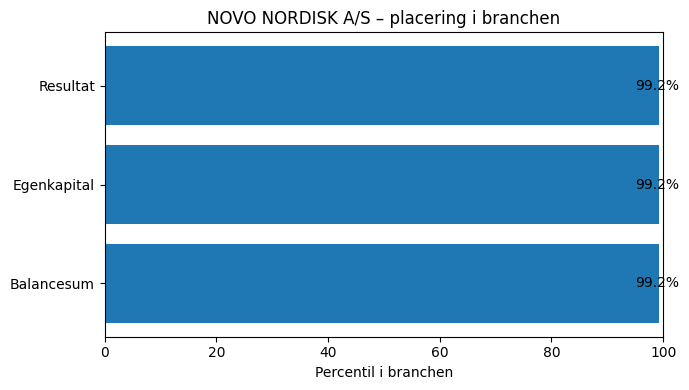

In [58]:
result = company_benchmark("24256790")
fig = create_benchmark_chart(result)

In [59]:
novo_industry = latest_data[
    latest_data["Branche"] == "Fremstilling af farmaceutiske præparater"
]

print(novo_industry["Status"].value_counts(dropna=False))

print("\nMedian for alle:")
print(format_amount(novo_industry["ProfitLoss"].median()))

print("\nMedian kun for Status = NORMAL:")
print(
    format_amount(
        novo_industry.loc[
            novo_industry["Status"] == "NORMAL",
            "ProfitLoss"
        ].median()
    )
)

Status
NORMAL                       128
OPLØSTEFTERERKLÆRING           2
UNDERFRIVILLIGLIKVIDATION      1
Name: count, dtype: int64

Median for alle:
-65.1 t.kr.

Median kun for Status = NORMAL:
-63.4 t.kr.


NOVO NORDISK A/S
Branche: Fremstilling af farmaceutiske præparater

Balancesum: 542.9 mia. kr.
Branchemedian: 3.7 mio. kr.
Placering: højere end 99.2% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 127 aktive virksomheder

Egenkapital: 194.0 mia. kr.
Branchemedian: 251.8 t.kr.
Placering: højere end 99.2% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 127 aktive virksomheder

Resultat: 102.4 mia. kr.
Branchemedian: -63.4 t.kr.
Placering: højere end 99.2% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 126 aktive virksomheder



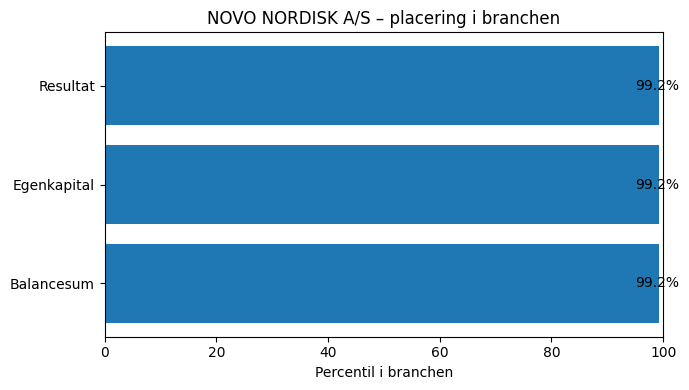

In [65]:
result = company_benchmark("24256790")

print(format_benchmark(result))

fig = create_benchmark_chart(result)
plt.close(fig)
fig

In [66]:
company_benchmark("SØSTRENE GRENE")

,CVR,Navn,Branche
6085,35140328,Søstrene Grenes Holding ApS,Administrations- og kontorserviceaktiviteter
6782,76220115,SØSTRENE GRENES IMPORT A/S,Engroshandel med kufferter og lædervarer


SØSTRENE GRENES IMPORT A/S
Branche: Engroshandel med kufferter og lædervarer

Balancesum: 1.0 mia. kr.
Branchemedian: 3.1 mio. kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 127 aktive virksomheder

Egenkapital: 422.8 mio. kr.
Branchemedian: 1.3 mio. kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 126 aktive virksomheder

Resultat: 127.2 mio. kr.
Branchemedian: 46.5 t.kr.
Placering: højere end 100.0% af de aktive virksomheder i branchen.
Sammenligningsgrundlag: 126 aktive virksomheder



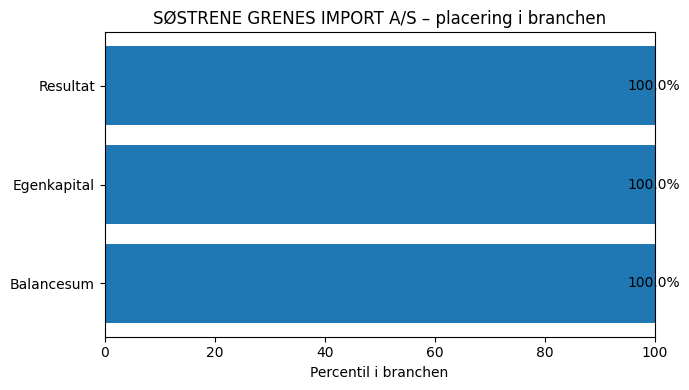

In [77]:
result = company_benchmark("76220115")

print(format_benchmark(result))

fig = create_benchmark_chart(result)
plt.close(fig)
fig

In [78]:
test_companies = latest_data[
    (latest_data["Status"].isin(["NORMAL", "Aktiv"])) &
    (latest_data["Assets"].between(5_000_000, 20_000_000)) &
    (latest_data["Equity"].notna()) &
    (latest_data["ProfitLoss"].notna())
]

test_companies[
    ["CVR", "Navn", "Branche", "Assets", "Equity", "ProfitLoss"]
].sample(10)

,CVR,Navn,Branche,Assets,Equity,ProfitLoss
185643,42752274,Karne Ejendomme ApS,Køb og salg af egen fast ejendom,11003176.0,-1893208.0,567635.0
275277,27460119,ANDERSSON HOLDING ApS,Ikke-finansielle holdingselskaber,9810534.0,8192203.0,151465.0
260537,27967116,ASAP ApS,Anden rengøring,7097939.0,5051965.0,736085.0
59993,25470583,VVS-BILEN A/S,"Installation af vvs-, varme- og klimaanlæg",12414026.0,5816745.0,74458.0
45698,13851840,HJØRRING PRODUKTHANDEL ApS,Engroshandel med affaldsprodukter,5223273.0,2150357.0,460621.0
250945,12885075,BUSDAN 32.1 ApS,Udlejning af erhvervsejendomme,15599000.0,15291000.0,-4341000.0
285814,38740121,Just Trees ApS,Dyrkning af andre flerårige afgrøder,6181119.0,5969602.0,1276437.0
270927,26536995,LIND POULSEN ApS,Detailhandel med kioskvarer,6519711.0,4399635.0,-71700.0
217984,29220247,NONVED HOLDING ApS,Ikke-finansielle holdingselskaber,16128766.0,13935509.0,-8202862.0
31578,40434577,Foxy Holding 2019 ApS,Ikke-finansielle holdingselskaber,15632299.0,15613176.0,2983909.0


Karne Ejendomme ApS
Branche: Køb og salg af egen fast ejendom

Balancesum: 11.0 mio. kr.
Branchemedian: 6.4 mio. kr.
Percentilplacering: 60.6% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7292 aktive virksomheder

Egenkapital: -1.9 mio. kr.
Branchemedian: 783.7 t.kr.
Percentilplacering: 3.7% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7286 aktive virksomheder

Resultat: 567.6 t.kr.
Branchemedian: 7.8 t.kr.
Percentilplacering: 77.4% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7284 aktive virksomheder



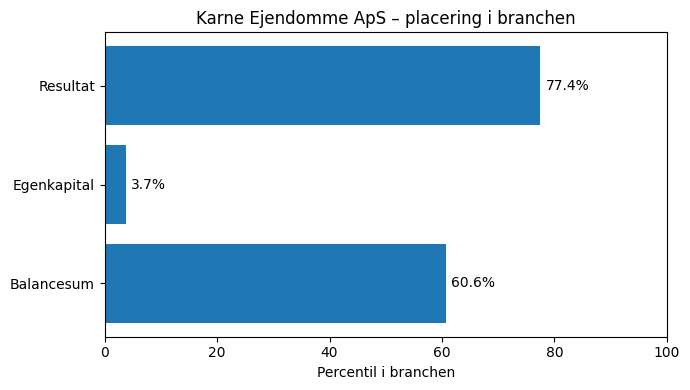

In [86]:
result = company_benchmark("Karne Ejendomme ApS")

print(format_benchmark(result))

fig = create_benchmark_chart(result)
plt.close(fig)
fig

#Step 5: Byg Gradio-prototype

På baggrund af den udviklede benchmarklogik bygges en simpel prototype, hvor brugeren kan søge på virksomhedsnavn eller CVR og få vist virksomhedens centrale regnskabstal, branchebenchmark og relative placering blandt aktive virksomheder i samme branche.

Gradio anvendes som interface, mens beregningerne fortsat udføres kontrolleret i Python på baggrund af det klargjorte datasæt.

In [87]:
!pip install -q gradio

In [88]:
import gradio as gr

In [89]:
def run_assistant(search_term):
    result = company_benchmark(search_term)

    if isinstance(result, str):
        return result, None

    if isinstance(result, pd.DataFrame):
        options = result.to_string(index=False)
        return f"Der blev fundet flere virksomheder:\n\n{options}\n\nPrøv igen med CVR-nummer.", None

    text_output = format_benchmark(result)
    chart_output = create_benchmark_chart(result)

    return text_output, chart_output

Karne Ejendomme ApS
Branche: Køb og salg af egen fast ejendom

Balancesum: 11.0 mio. kr.
Branchemedian: 6.4 mio. kr.
Percentilplacering: 60.6% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7292 aktive virksomheder

Egenkapital: -1.9 mio. kr.
Branchemedian: 783.7 t.kr.
Percentilplacering: 3.7% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7286 aktive virksomheder

Resultat: 567.6 t.kr.
Branchemedian: 7.8 t.kr.
Percentilplacering: 77.4% blandt aktive virksomheder i branchen.
Sammenligningsgrundlag: 7284 aktive virksomheder



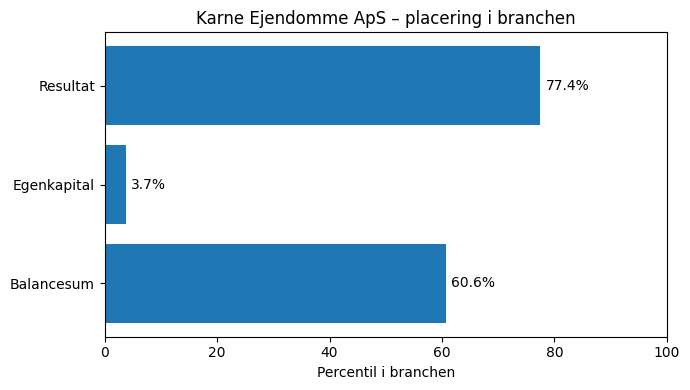

In [91]:
text, chart = run_assistant("Karne Ejendomme ApS")

print(text)

plt.close(chart)
chart

In [92]:
with gr.Blocks(title="Regnskabsassistent") as demo:

    gr.Markdown(
        """
        # Regnskabsassistent
        Få hurtigt overblik over en virksomheds økonomiske position og sammenlign den med aktive virksomheder i samme branche.
        """
    )

    search_input = gr.Textbox(
        label="Virksomhed",
        placeholder="Skriv virksomhedsnavn eller CVR-nummer..."
    )

    search_button = gr.Button("Analyser virksomhed")

    text_output = gr.Textbox(
        label="Analyse",
        lines=15
    )

    plot_output = gr.Plot(
        label="Placering i branchen"
    )

    search_button.click(
        fn=run_assistant,
        inputs=search_input,
        outputs=[text_output, plot_output]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1d127e1df6725d3f0c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
